In [154]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from multiprocessing import Pool
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.feature_selection import RFE

In [146]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from scipy.stats import spearmanr

In [41]:
from mordred import Calculator, descriptors
calc = Calculator(descriptors, ignore_3D=True)

In [12]:
from src.qsar_train import run_qsar_cv

In [4]:
# manually define project root
PROJECT_ROOT = Path("/Users/shreechatterjee/jak-selectivity-screening")

# set working directory
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/shreechatterjee/jak-selectivity-screening


In [6]:
shared_df = pd.read_csv("data/ChEMBL/ChEMBL Data Preprocessing/ic50_shared_compounds.tsv", sep='\t')
shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."


In [8]:
# fold selectivity: how many-fold more potent the compound is on its stronger target
fold = shared_df[['JAK1_IC50_nM', 'JAK2_IC50_nM']].max(axis=1) / shared_df[['JAK1_IC50_nM', 'JAK2_IC50_nM']].min(axis=1)

SELECTIVITY_THRESHOLD = 5  # fold-change cutoff to call a compound "selective" at all — adjust as needed

shared_df['fold_selectivity'] = fold

# 1. Selective (yes/no)
shared_df['selective'] = np.where(fold >= SELECTIVITY_THRESHOLD, 'Yes', 'No')

# 2. Selective for which protein
shared_df['selective_for'] = np.select(
    [
        (fold >= SELECTIVITY_THRESHOLD) & (shared_df['JAK1_IC50_nM'] < shared_df['JAK2_IC50_nM']),
        (fold >= SELECTIVITY_THRESHOLD) & (shared_df['JAK1_IC50_nM'] > shared_df['JAK2_IC50_nM']),
    ],
    ['JAK1', 'JAK2'],
    default='None'
)

# 3. Continuous fold-selectivity is just `fold_selectivity` above

# 4. Selectivity category (binned)
bins   = [0, 2, 5, 10, 20, 30, 50, np.inf]
labels = ['<2x', '2x', '5x', '10x', '20x', '30x', '50x+']
shared_df['selectivity_category'] = pd.cut(fold, bins=bins, labels=labels, right=False)

shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",7.500000,Yes,JAK1,5x
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",3.380952,No,None,2x
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.545455,Yes,JAK1,5x
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.000000,No,None,2x
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.822785,Yes,JAK1,5x
...,...,...,...,...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.952381,No,None,2x
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.197802,No,None,2x
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.325581,No,None,2x
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.454545,No,None,2x


In [44]:
jak2_selective_df = shared_df.query("selective_for == 'JAK2' and fold_selectivity >= 5")
jak1_selective_df = shared_df.query("selective_for == 'JAK1' and fold_selectivity >= 5")
non_selective_df = shared_df.query("selective == 'No'")

In [46]:
len(jak2_selective_df)

267

In [16]:
qsar_df = shared_df[['smiles', 'JAK1_IC50_nM', 'JAK2_IC50_nM']]

In [18]:
qsar_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6
...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0


In [20]:
qsar_df['JAK1_pIC50'] = -np.log10(qsar_df['JAK1_IC50_nM'] * 1e-9)
qsar_df['JAK2_pIC50'] = -np.log10(qsar_df['JAK2_IC50_nM'] * 1e-9)
qsar_df["delta_pIC50"] = qsar_df["JAK2_pIC50"] - qsar_df["JAK1_pIC50"]

/var/folders/jn/0kbctjzn2tl1p83gh95ymtw00000gn/T/ipykernel_8325/1471609724.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qsar_df['JAK1_pIC50'] = -np.log10(qsar_df['JAK1_IC50_nM'] * 1e-9)
/var/folders/jn/0kbctjzn2tl1p83gh95ymtw00000gn/T/ipykernel_8325/1471609724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qsar_df['JAK2_pIC50'] = -np.log10(qsar_df['JAK2_IC50_nM'] * 1e-9)
/var/folders/jn/0kbctjzn2tl1p83gh95ymtw00000gn/T/ipykernel_8325/1471609724.py:3: SettingWithCopyWarning: 
A value is trying to

In [22]:
qsar_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,JAK1_pIC50,JAK2_pIC50,delta_pIC50
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,9.397940,8.522879,-0.875061
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,7.677781,7.148742,-0.529039
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,8.958607,8.214670,-0.743937
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,8.853872,8.552842,-0.301030
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,9.102373,8.337242,-0.765131
...,...,...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,6.677781,6.207608,-0.470172
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,8.040959,7.698970,-0.341989
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,8.366532,8.000000,-0.366532
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,7.657577,7.267606,-0.389971


In [24]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def murcko(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(
        MurckoScaffold.GetScaffoldForMol(mol)
    )

qsar_df["scaffold"] = qsar_df["smiles"].apply(murcko)

n_scaffolds = qsar_df["scaffold"].nunique()
print(f"Unique scaffolds: {n_scaffolds}")

Unique scaffolds: 1876


/var/folders/jn/0kbctjzn2tl1p83gh95ymtw00000gn/T/ipykernel_8325/3042635324.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qsar_df["scaffold"] = qsar_df["smiles"].apply(murcko)


In [26]:
scaffold_counts = qsar_df["scaffold"].value_counts()

print(scaffold_counts.describe())

count    1876.000000
mean        3.080490
std         8.835349
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       240.000000
Name: count, dtype: float64


In [28]:
scaffold_counts = qsar_df["scaffold"].value_counts()

top10_pct = scaffold_counts.head(10).sum() / len(qsar_df)
top50_pct = scaffold_counts.head(50).sum() / len(qsar_df)

print(top10_pct)
print(top50_pct)

0.1566014881467382
0.35611697525523445


In [31]:
qsar_df.to_csv("qsar_df.csv")

## QSAR - Only Morgan Fingerprints

### Regression Training

In [30]:
results_dummy = run_qsar_cv(
    qsar_df,
    model="dummy",
    split="random",
    fp_type="binary",
    n_folds=5
)

2026-08-01 07:48:49 | INFO | ======================================================================
2026-08-01 07:48:49 | INFO | Starting QSAR cross-validation
2026-08-01 07:48:49 | INFO | Rows: 5779 | Model: dummy | Split: random | Fingerprint: binary | Folds: 5
2026-08-01 07:48:49 | INFO | ======================================================================
2026-08-01 07:48:49 | INFO | Input validation passed
2026-08-01 07:48:49 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 07:48:50 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 07:48:50 | INFO | Fingerprint generation took 1.1s
2026-08-01 07:48:50 | INFO | Preparing targets...
2026-08-01 07:48:50 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 07:48:50 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 07:48:50 | INFO | Fold 1 | predicting...
/Users/shreechatterjee/jak-selectivity-screening/src/qsar_train.py:194: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)
2026-08-01 07:48:50 | INFO | Fold 1 done in 0.0s | R2=-0.0000 | RMSE=0.7435 | MAE=0.5799 | Spearman=0.0000
2026-08-01 07:48:50 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 07:48:50 | INFO | Fold 2 | predicting...
/Users/shreechatterjee/jak-selectivity-screening/src/qsar_train.py:194: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)
2026-08-01 07:48:50 | INFO | Fold 2 done in 0.0s | R2=-0.0000 | RMSE=0.7424 | MAE=0.5815 | Spearman=0.0000
2026-08-01 07:48:50 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 07:48:50 | INFO 

In [49]:
results_rf = run_qsar_cv(
    qsar_df,
    model="rf",
    split="random",
    fp_type="binary",
    n_folds=5
)

2026-08-01 08:09:47 | INFO | ======================================================================
2026-08-01 08:09:47 | INFO | Starting QSAR cross-validation
2026-08-01 08:09:47 | INFO | Rows: 5779 | Model: rf | Split: random | Fingerprint: binary | Folds: 5
2026-08-01 08:09:47 | INFO | ======================================================================
2026-08-01 08:09:47 | INFO | Input validation passed
2026-08-01 08:09:47 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 08:09:48 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 08:09:48 | INFO | Fingerprint generation took 1.1s
2026-08-01 08:09:48 | INFO | Preparing targets...
2026-08-01 08:09:48 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 08:09:48 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 08:10:27 | INFO | Fold 1 | predicting...
2026-08-01 08:10:27 | INFO | Fold 1 done in 39.2s | R2=0.8199 | RMSE=0.3156 | MAE=0.2253 | Spearman=0.8938
2026-08-01 08:10:27 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 08:11:06 | INFO | Fold 2 | predicting...
2026-08-01 08:11:06 | INFO | Fold 2 done in 38.9s | R2=0.8375 | RMSE=0.2993 | MAE=0.2119 | Spearman=0.9049
2026-08-01 08:11:06 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 08:11:45 | INFO | Fold 3 | predicting...
2026-08-01 08:11:45 | INFO | Fold 3 done in 38.6s | R2=0.8490 | RMSE=0.3000 | MAE=0.2170 | Spearman=0.9112
2026-08-01 08:11:45 | INFO | Fold 4/5 | train=4623 | test=1156 | training model...
2026-08-01 08:12:23 | INFO | Fold 4 | predicting...
2026-08-01 08:12:23 | INFO | Fold 4 done in 38.3s | R2=0.8293 | RMSE=0.3012 | MAE=0.2154 | Spearman=0.9049
2026-08-01 08:12:23 | INFO | Fol

In [50]:
results_rf_scaffold = run_qsar_cv(
    qsar_df,
    model="rf",
    split="scaffold",
    fp_type="binary",
    n_folds=5
)

2026-08-01 08:13:03 | INFO | ======================================================================
2026-08-01 08:13:03 | INFO | Starting QSAR cross-validation
2026-08-01 08:13:03 | INFO | Rows: 5779 | Model: rf | Split: scaffold | Fingerprint: binary | Folds: 5
2026-08-01 08:13:03 | INFO | ======================================================================
2026-08-01 08:13:03 | INFO | Input validation passed
2026-08-01 08:13:03 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 08:13:04 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 08:13:04 | INFO | Fingerprint generation took 1.1s
2026-08-01 08:13:04 | INFO | Preparing targets...
2026-08-01 08:13:04 | INFO | Using scaffold groups for GroupKFold
2026-08-01 08:13:04 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 08:13:04 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 08:13:46 | INFO | Fold 1 | predicting...
2026-08-01 08:13:46 | INFO | Fold 1 done in 41.7s | R2=0.7850 | RMSE=0.3264 | MAE=0.2335 | Spearman=0.8854
2026-08-01 08:13:46 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 08:14:27 | INFO | Fold 2 | predicting...
2026-08-01 08:14:27 | INFO | Fold 2 done in 40.8s | R2=0.7697 | RMSE=0.3512 | MAE=0.2557 | Spearman=0.8711
2026-08-01 08:14:27 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 08:15:08 | INFO | Fold 3 | predicting...
2026-08-01 08:15:08 | INFO | Fold 3 done in 41.0s | R2=0.7947 | RMSE=0.3496 | MAE=0.2530 | Spearman=0.8792
2026-08-01 08:15:08 | INFO | Fold 4/5 | train=4623 | test=1156 | training model...
2026-08-01 08:15:46 | INFO | Fold 4 | predicting...
2026-08-01 08:15:46 | INFO | Fold 4 done in 38.5s | R2=0.8208 | RMSE=0.3337 | MAE=0.2480 | Spearman=0.8842
2026-08-01 08:15:46 | INFO | Fol

In [32]:
results_xgb = run_qsar_cv(
    qsar_df,
    model="xgb",
    split="random",
    fp_type="binary",
    n_folds=5
)

2026-08-01 07:51:27 | INFO | ======================================================================
2026-08-01 07:51:27 | INFO | Starting QSAR cross-validation
2026-08-01 07:51:27 | INFO | Rows: 5779 | Model: xgb | Split: random | Fingerprint: binary | Folds: 5
2026-08-01 07:51:27 | INFO | ======================================================================
2026-08-01 07:51:27 | INFO | Input validation passed
2026-08-01 07:51:27 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 07:51:28 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 07:51:28 | INFO | Fingerprint generation took 1.0s
2026-08-01 07:51:28 | INFO | Preparing targets...
2026-08-01 07:51:28 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 07:51:28 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 07:51:28 | INFO | Fold 1 | predicting...
2026-08-01 07:51:28 | INFO | Fold 1 done in 0.4s | R2=0.8106 | RMSE=0.3236 | MAE=0.2404 | Spearman=0.8845
2026-08-01 07:51:28 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 07:51:29 | INFO | Fold 2 | predicting...
2026-08-01 07:51:29 | INFO | Fold 2 done in 0.4s | R2=0.8234 | RMSE=0.3119 | MAE=0.2297 | Spearman=0.8945
2026-08-01 07:51:29 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 07:51:29 | INFO | Fold 3 | predicting...
2026-08-01 07:51:29 | INFO | Fold 3 done in 0.5s | R2=0.8412 | RMSE=0.3076 | MAE=0.2321 | Spearman=0.9054
2026-08-01 07:51:29 | INFO | Fold 4/5 | train=4623 | test=1156 | training model...
2026-08-01 07:51:30 | INFO | Fold 4 | predicting...
2026-08-01 07:51:30 | INFO | Fold 4 done in 0.4s | R2=0.8141 | RMSE=0.3144 | MAE=0.2294 | Spearman=0.8969
2026-08-01 07:51:30 | INFO | Fold 5/

In [34]:
results_xgb_scaffold = run_qsar_cv(
    qsar_df,
    model="xgb",
    split="scaffold",
    fp_type="binary",
    n_folds=5
)

2026-08-01 07:52:04 | INFO | ======================================================================
2026-08-01 07:52:04 | INFO | Starting QSAR cross-validation
2026-08-01 07:52:04 | INFO | Rows: 5779 | Model: xgb | Split: scaffold | Fingerprint: binary | Folds: 5
2026-08-01 07:52:04 | INFO | ======================================================================
2026-08-01 07:52:04 | INFO | Input validation passed
2026-08-01 07:52:04 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 07:52:05 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 07:52:05 | INFO | Fingerprint generation took 1.1s
2026-08-01 07:52:05 | INFO | Preparing targets...
2026-08-01 07:52:05 | INFO | Using scaffold groups for GroupKFold
2026-08-01 07:52:05 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 07:52:05 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 07:52:05 | INFO | Fold 1 | predicting...
2026-08-01 07:52:05 | INFO | Fold 1 done in 0.4s | R2=0.7926 | RMSE=0.3206 | MAE=0.2357 | Spearman=0.8910
2026-08-01 07:52:05 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 07:52:06 | INFO | Fold 2 | predicting...
2026-08-01 07:52:06 | INFO | Fold 2 done in 0.4s | R2=0.7650 | RMSE=0.3548 | MAE=0.2655 | Spearman=0.8690
2026-08-01 07:52:06 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 07:52:06 | INFO | Fold 3 | predicting...
2026-08-01 07:52:06 | INFO | Fold 3 done in 0.4s | R2=0.7859 | RMSE=0.3571 | MAE=0.2645 | Spearman=0.8717
2026-08-01 07:52:06 | INFO | Fold 4/5 | train=4623 | test=1156 | training model...
2026-08-01 07:52:06 | INFO | Fold 4 | predicting...
2026-08-01 07:52:06 | INFO | Fold 4 done in 0.4s | R2=0.8074 | RMSE=0.3459 | MAE=0.2637 | Spearman=0.8775
2026-08-01 07:52:06 | INFO | Fold 5/

In [38]:
results_svr = run_qsar_cv(
    qsar_df,
    model="svr",
    split="random",
    fp_type="binary",
    n_folds=5
)

2026-08-01 07:54:33 | INFO | ======================================================================
2026-08-01 07:54:33 | INFO | Starting QSAR cross-validation
2026-08-01 07:54:33 | INFO | Rows: 5779 | Model: svr | Split: random | Fingerprint: binary | Folds: 5
2026-08-01 07:54:33 | INFO | ======================================================================
2026-08-01 07:54:33 | INFO | Input validation passed
2026-08-01 07:54:33 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 07:54:34 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 07:54:34 | INFO | Fingerprint generation took 1.0s
2026-08-01 07:54:34 | INFO | Preparing targets...
2026-08-01 07:54:34 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 07:54:34 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 07:55:09 | INFO | Fold 1 | predicting...
2026-08-01 07:55:21 | INFO | Fold 1 done in 46.5s | R2=0.7420 | RMSE=0.3777 | MAE=0.2750 | Spearman=0.8599
2026-08-01 07:55:21 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 07:55:55 | INFO | Fold 2 | predicting...
2026-08-01 07:56:06 | INFO | Fold 2 done in 45.7s | R2=0.7531 | RMSE=0.3688 | MAE=0.2695 | Spearman=0.8663
2026-08-01 07:56:06 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 07:56:42 | INFO | Fold 3 | predicting...
2026-08-01 07:56:53 | INFO | Fold 3 done in 46.6s | R2=0.7818 | RMSE=0.3606 | MAE=0.2603 | Spearman=0.8887
2026-08-01 07:56:53 | INFO | Fold 4/5 | train=4623 | test=1156 | training model...
2026-08-01 07:57:28 | INFO | Fold 4 | predicting...
2026-08-01 07:57:39 | INFO | Fold 4 done in 46.4s | R2=0.7666 | RMSE=0.3522 | MAE=0.2619 | Spearman=0.8774
2026-08-01 07:57:39 | INFO | Fol

In [42]:
results_svr_scaffold = run_qsar_cv(
    qsar_df,
    model="svr",
    split="scaffold",
    fp_type="binary",
    n_folds=5
)

2026-08-01 08:00:05 | INFO | ======================================================================
2026-08-01 08:00:05 | INFO | Starting QSAR cross-validation
2026-08-01 08:00:05 | INFO | Rows: 5779 | Model: svr | Split: scaffold | Fingerprint: binary | Folds: 5
2026-08-01 08:00:05 | INFO | ======================================================================
2026-08-01 08:00:05 | INFO | Input validation passed
2026-08-01 08:00:05 | INFO | Generating Morgan fingerprints...


Fingerprints:   0%|          | 0/5779 [00:00<?, ?it/s]

2026-08-01 08:00:06 | INFO | Fingerprint matrix shape: (5779, 2048)
2026-08-01 08:00:06 | INFO | Fingerprint generation took 1.0s
2026-08-01 08:00:06 | INFO | Preparing targets...
2026-08-01 08:00:06 | INFO | Using scaffold groups for GroupKFold
2026-08-01 08:00:06 | INFO | Creating CV splitter...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-08-01 08:00:06 | INFO | Fold 1/5 | train=4623 | test=1156 | training model...
2026-08-01 08:00:42 | INFO | Fold 1 | predicting...
2026-08-01 08:00:53 | INFO | Fold 1 done in 46.2s | R2=0.6687 | RMSE=0.4052 | MAE=0.2911 | Spearman=0.8431
2026-08-01 08:00:53 | INFO | Fold 2/5 | train=4623 | test=1156 | training model...
2026-08-01 08:01:27 | INFO | Fold 2 | predicting...
2026-08-01 08:01:38 | INFO | Fold 2 done in 45.4s | R2=0.6530 | RMSE=0.4311 | MAE=0.3150 | Spearman=0.8346
2026-08-01 08:01:38 | INFO | Fold 3/5 | train=4623 | test=1156 | training model...
2026-08-01 08:02:13 | INFO | Fold 3 | predicting...
2026-08-01 08:02:24 | INFO | Fold 3 done in 45.6s | R2=0.6810 | RMSE=0.4358 | MAE=0.3106 | Spearman=0.8467
2026-08-01 08:02:24 | INFO | Fold 4/5 | train=4623 | test=1156 | training model...
2026-08-01 08:02:58 | INFO | Fold 4 | predicting...
2026-08-01 08:03:09 | INFO | Fold 4 done in 45.5s | R2=0.7024 | RMSE=0.4300 | MAE=0.3227 | Spearman=0.8546
2026-08-01 08:03:09 | INFO | Fol

### Analysis of Enrichment

In [260]:
pred_df = results_rf_scaffold["predictions"]

threshold = 0.7

pred_df["actual_selective"] = (
    pred_df["y_true"] >= threshold
).astype(int)

pred_df["pred_selective"] = (
    pred_df["y_pred"] >= threshold
).astype(int)

In [262]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

precision = precision_score(
    pred_df["actual_selective"],
    pred_df["pred_selective"]
)

recall = recall_score(
    pred_df["actual_selective"],
    pred_df["pred_selective"]
)

f1 = f1_score(
    pred_df["actual_selective"],
    pred_df["pred_selective"]
)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.7514450867052023
Recall: 0.5
F1: 0.6004618937644342


In [264]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(
    pred_df["actual_selective"],
    pred_df["y_pred"]
)

print(ap)

0.7140064251344795


In [266]:
ranked = pred_df.sort_values(
    "y_pred",
    ascending=False
)

top_1pct = ranked.head(int(0.01 * len(ranked)))
(top_1pct["y_true"] >= 0.7).mean()

0.8771929824561403

In [268]:
top_5pct = ranked.head(int(0.05 * len(ranked)))
(top_5pct["y_true"] >= 0.7).mean()

0.6041666666666666

In [270]:
top_10pct = ranked.head(int(0.10 * len(ranked)))
(top_10pct["y_true"] >= 0.7).mean()

0.41767764298093585

In [272]:
top_100 = ranked.head(100)

recovered = (
    top_100["y_true"] >= 0.7
).sum()

total_selective = (
    pred_df["y_true"] >= 0.7
).sum()

recall_at_100 = recovered / total_selective
recall_at_100

0.33076923076923076

In [274]:
pred_df[pred_df["y_true"] >= 1.0]
(pred_df.loc[pred_df["y_true"] >= 1.0, "y_pred"] >= 1.0).mean()

0.38095238095238093

In [276]:
ef1 = top_1pct["actual_selective"].mean() / baseline
ef5 = top_5pct["actual_selective"].mean() / baseline
ef10 = top_10pct["actual_selective"].mean() / baseline
print(ef1, ef5, ef10)

19.497300944669362 13.428766025641025 9.2836888414878


In [278]:
top1 = ranked.head(int(0.01 * len(ranked)))

top1["y_true"].describe()

count    57.000000
mean      1.329720
std       0.512859
min       0.000000
25%       0.869140
50%       1.372093
75%       1.755875
max       2.342423
Name: y_true, dtype: float64

<Axes: >

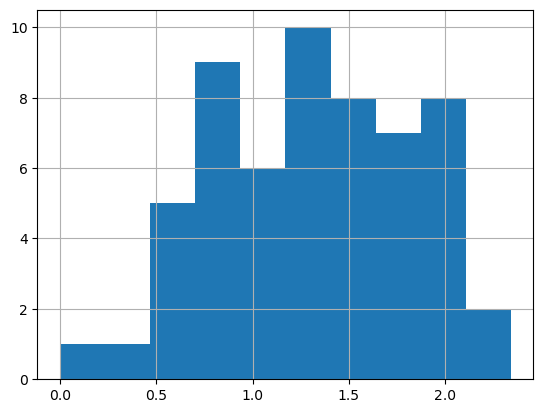

In [280]:
top1["y_true"].hist()

In [282]:
for pct in [0.01, 0.05, 0.10]:
    top = ranked.head(int(pct * len(ranked)))
    print(
        pct,
        top["y_true"].mean(),
        top["y_true"].median()
    )

0.01 1.3297204439939663 1.3720933514894265
0.05 0.8362182638862409 0.8037067092360441
0.1 0.6129581963701483 0.6020599913279625


In [284]:
fractions = np.linspace(0.01, 0.5, 50)

means = []

for frac in fractions:
    top = ranked.head(int(frac * len(ranked)))
    means.append(top["y_true"].mean())

plt.plot(fractions * 100, means)
plt.xlabel("Top ranked compounds (%)")
plt.ylabel("Mean actual ΔpIC50")
plt.title("Selectivity enrichment curve")

NameError: name 'plt' is not defined

#### QSAR Model Performance Summary

| Model | Split | R² | RMSE | MAE | Spearman ρ |
|---|---|---:|---:|---:|---:|
| RF | Random | 0.8292 ± 0.0150 | 0.3081 ± 0.0113 | 0.2195 ± 0.0068 | 0.9011 ± 0.0086 |
| RF | Scaffold | 0.7842 ± 0.0264 | 0.3443 ± 0.0138 | 0.2495 ± 0.0096 | 0.8780 ± 0.0071 |
| XGB | Random | 0.8185 ± 0.0147 | 0.3176 ± 0.0093 | 0.2342 ± 0.0053 | 0.8926 ± 0.0096 |
| XGB | Scaffold | 0.7539 ± 0.0772 | 0.3648 ± 0.0474 | 0.2656 ± 0.0223 | 0.8686 ± 0.0212 |

#### Classification Performance (ΔpIC50 ≥ 0.7)

| Model | Split | Precision | Recall | F1 | PR-AUC |
|---|---|---:|---:|---:|---:|
| RF | Random | 0.7665 | 0.5808 | 0.6608 | 0.7356 |
| RF | Scaffold | 0.7514 | 0.5000 | 0.6005 | 0.7140 |
| XGB | Random | 0.7419 | 0.5308 | 0.6188 | 0.7138 |
| XGB | Scaffold | 0.7253 | 0.5077 | 0.5973 | 0.7142 |

#### Classification Performance (ΔpIC50 ≥ 1.0)

| Model | Split | Precision | Recall | F1 | PR-AUC |
|---|---|---:|---:|---:|---:|
| RF | Random | 0.7763 | 0.4683 | 0.5842 | 0.6529 |
| RF | Scaffold | 0.7059 | 0.3810 | 0.4948 | 0.5939 |
| XGB | Random | 0.7297 | 0.4286 | 0.5400 | 0.6366 |
| XGB | Scaffold | 0.6714 | 0.3730 | 0.4800 | 0.5824 |

#### Early Enrichment Metrics (ΔpIC50 ≥ 0.7)

| Model | Split | EF1% | EF5% | EF10% | Recall@100 |
|---|---|---:|---:|---:|---:|
| RF | Random | 20.67× | 14.05× | 9.17× | 0.3231 |
| RF | Scaffold | 19.50× | 13.43× | 9.28× | 0.3308 |
| XGB | Random | 20.67× | 13.74× | 9.13× | 0.3346 |
| XGB | Scaffold | 20.67× | 13.81× | 9.13× | 0.3308 |

#### Early Enrichment Metrics (ΔpIC50 ≥ 1.0)

| Model | Split | EF1% | EF5% | EF10% |
|---|---|---:|---:|---:|
| RF | Random | 18.72× | 7.87× | 4.43× |
| RF | Scaffold | 15.60× | 7.65× | 4.47× |
| XGB | Random | 18.72× | 7.49× | 4.51× |
| XGB | Scaffold | 15.60× | 7.65× | 4.47× |

#### Top-Ranked RF Compounds (Random CV)

| Ranked Fraction | Mean ΔpIC50 | Median ΔpIC50 | Approx. Mean Fold Selectivity |
|---|---:|---:|---:|
| Top 1% | 1.33 | 1.37 | ~21× |
| Top 5% | 0.84 | 0.80 | ~7× |
| Top 10% | 0.61 | 0.60 | ~4× |

#### Key Findings

- Random Forest outperformed XGBoost across all regression metrics.
- Scaffold CV resulted in only a modest performance decrease despite 1,876 unique Murcko scaffolds.
- RF scaffold CV achieved:
  - R² = 0.784
  - Spearman ρ = 0.878
  - PR-AUC = 0.714 for identifying compounds with ΔpIC50 ≥ 0.7
  - EF1% = 19.5×
- The top 1% of RF-ranked compounds had a mean ΔpIC50 of 1.33 (≈21-fold JAK2 selectivity).
- Strong enrichment under scaffold CV suggests the model can effectively prioritize novel JAK2-selective chemotypes.

## QSAR - Morgan Fingerprints + Molecular Descriptors

### Descriptor Preprocessing

In [27]:
qsar_df = pd.read_csv("data/qsar_df.csv")

In [29]:
qsar_df = qsar_df[["smiles", "delta_pIC50"]]

In [31]:
qsar_df

,smiles,delta_pIC50
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,-0.875061
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,-0.529039
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,-0.743937
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,-0.301030
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,-0.765131
...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,-0.470172
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,-0.341989
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,-0.366532
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,-0.389971


In [33]:
qsar_df_sample = qsar_df.head(1)

In [37]:
qsar_df_sample.to_csv("qsar_df_sample.csv")

In [63]:
# Convert SMILES → RDKit molecules
mols = [Chem.MolFromSmiles(s) for s in qsar_df["smiles"]]

# Calculate Mordred descriptors using 7 CPU cores
mordred_df = calc.pandas(mols, nproc=7)

# Combine with original data
qsar_df_mordred = pd.concat(
    [
        qsar_df.reset_index(drop=True),
        mordred_df.reset_index(drop=True)
    ],
    axis=1
)

  1%|          | 34/5779 [00:03<06:59, 13.69it/s] 

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 13%|█▎        | 759/5779 [00:59<13:37,  6.14it/s]

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 13%|█▎        | 761/5779 [01:00<15:15,  5.48it/s]

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 49%|████▊     | 2811/5779 [03:35<07:09,  6.91it/s]

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 5779/5779 [07:28<00:00, 12.89it/s]


In [67]:
qsar_df_mordred.head()

,smiles,delta_pIC50,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,-0.875061,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,27.237223,2.522971,4.913351,27.237223,...,10.068451,70.042387,333.058908,9.251636,778,32,112.0,137.0,4.777778,4.388889
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,-0.529039,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,1,34.68582,2.523672,4.916166,34.68582,...,10.307652,78.585257,493.952390,11.760771,1784,41,148.0,180.0,6.611111,5.500000
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,-0.743937,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,1,35.271102,2.52347,4.917432,35.271102,...,10.285377,77.274070,410.085457,9.113010,1805,41,146.0,176.0,6.0,5.555556
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,-0.301030,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,1,33.772491,2.523557,4.916014,33.772491,...,10.247751,77.222027,400.064721,9.525351,1590,38,142.0,172.0,5.75,5.305556
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,-0.765131,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,1,33.772491,2.523557,4.916014,33.772491,...,10.247751,77.222027,416.041878,9.905759,1590,38,142.0,172.0,5.75,5.305556


In [71]:
X = qsar_df_mordred.drop(columns=["smiles", "delta_pIC50"])
y = qsar_df_mordred["delta_pIC50"]

In [73]:
X = X.apply(pd.to_numeric, errors="coerce")

In [75]:
X = X.replace([np.inf, -np.inf], np.nan)

In [83]:
missing_fraction = X.isna().mean()

print(missing_fraction.describe())

count    1613.000000
mean        0.095370
std         0.282566
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000346
max         1.000000
dtype: float64


In [87]:
missing_fraction = X.isna().mean()

print("Total descriptors:", len(missing_fraction))
print("100% missing:", (missing_fraction == 1).sum())
print(">50% missing:", (missing_fraction > 0.50).sum())
print(">10% missing:", (missing_fraction > 0.10).sum())
print(">5% missing:", (missing_fraction > 0.05).sum())
print(">1% missing:", (missing_fraction > 0.01).sum())
print("Any missing:", (missing_fraction > 0).sum())

Total descriptors: 1613
100% missing: 98
>50% missing: 148
>10% missing: 180
>5% missing: 180
>1% missing: 181
Any missing: 455


In [91]:
X = X.loc[:, X.isna().mean() <= 0.05]
print(X.shape)

(5779, 1433)


In [93]:
X = X.loc[:, X.nunique() > 1]

print("Descriptors remaining:", X.shape[1])

Descriptors remaining: 1285


In [97]:
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

### Descriptor Filtering

In [101]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

X = X.drop(columns=to_drop)

print("Descriptors remaining:", X.shape[1])

Descriptors remaining: 414


In [104]:
X

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpMAD_A,VE1_A,VR1_A,VR3_A,nAromAtom,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,TopoShapeIndex,SRW05
0,0.0,0.0,27.237223,2.522971,4.913351,1.361861,3.906825,175.777738,5.862368,12.0,...,0.031250,0.036782,0.020386,0.013064,0.014203,0.014137,0.008386,0.010782,1.000000,3.044522
1,0.0,1.0,34.685820,2.523672,4.916166,1.334070,4.053947,507.592529,7.185190,17.0,...,0.046748,0.032207,0.020741,0.016681,0.012549,0.009885,0.008282,0.005440,0.857143,3.433987
2,0.0,1.0,35.271102,2.523470,4.917432,1.356581,4.006787,746.225291,7.570539,18.0,...,0.030488,0.038078,0.014419,0.014635,0.015509,0.008076,0.007275,0.005929,1.000000,3.044522
3,0.0,1.0,33.772491,2.523557,4.916014,1.350900,4.018593,512.835441,7.156246,17.0,...,0.041301,0.031852,0.017917,0.014825,0.013023,0.008818,0.007317,0.004903,0.857143,3.433987
4,0.0,1.0,33.772491,2.523557,4.916014,1.350900,4.018593,512.835441,7.156246,17.0,...,0.041301,0.031852,0.017917,0.014825,0.013023,0.008818,0.007317,0.004903,0.857143,3.433987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,0.0,1.0,34.098497,2.524925,4.922391,1.363940,4.032329,549.068472,7.224514,18.0,...,0.033654,0.030751,0.010008,0.012902,0.008333,0.006683,0.005827,0.002939,1.000000,3.044522
5775,0.0,1.0,32.856258,2.523485,4.915890,1.369011,3.996329,471.163969,7.030675,17.0,...,0.033951,0.031476,0.014910,0.012659,0.013602,0.007608,0.006231,0.004224,1.000000,3.433987
5776,0.0,1.0,32.856258,2.523485,4.915890,1.369011,3.996329,471.163969,7.030675,17.0,...,0.033951,0.031476,0.014910,0.012659,0.013602,0.007608,0.006231,0.004224,1.000000,3.433987
5777,0.0,1.0,32.856258,2.523485,4.915890,1.369011,3.996329,471.163969,7.030675,17.0,...,0.033951,0.031476,0.014910,0.012659,0.013602,0.007608,0.006231,0.004224,1.000000,3.433987


In [110]:
mols = [Chem.MolFromSmiles(smiles) for smiles in qsar_df["smiles"]]

invalid = sum(mol is None for mol in mols)
print("Invalid SMILES:", invalid)

Invalid SMILES: 0


In [127]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048,
    includeChirality=True,
    useBondTypes=True
)

morgan_fps = [
    morgan_generator.GetFingerprint(Chem.MolFromSmiles(smiles))
    for smiles in qsar_df["smiles"]
]

X_morgan = np.array(
    [list(fp) for fp in morgan_fps],
    dtype=np.uint8
)

print(X_morgan.shape)

(5779, 2048)


In [133]:
y = qsar_df["delta_pIC50"].to_numpy()

In [135]:
X_combined = np.hstack([
    X_morgan,
    X.to_numpy()
])

print("Morgan:", X_morgan.shape)
print("Mordred:", X.shape)
print("Combined:", X_combined.shape)

Morgan: (5779, 2048)
Mordred: (5779, 414)
Combined: (5779, 2462)


### RFE

In [142]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

qsar_df["scaffold"] = qsar_df["smiles"].apply(get_scaffold)

In [144]:
print("qsar_df:", len(qsar_df))
print("y:", len(y))
print("Morgan:", X_morgan.shape)
print("Mordred:", X.shape)
print("Combined:", X_combined.shape)
print("Scaffolds:", len(qsar_df["scaffold"]))

qsar_df: 5779
y: 5779
Morgan: (5779, 2048)
Mordred: (5779, 414)
Combined: (5779, 2462)
Scaffolds: 5779


In [150]:
groups = qsar_df["scaffold"].to_numpy()

splitter = GroupKFold(n_splits=5)

fold_metrics = []
prediction_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(
    splitter.split(X_combined, y, groups=groups),
    start=1
):
    print(f"Fold {fold_idx}/5")

    # EXACT same RF as original script
    model = RandomForestRegressor(
        random_state=42
    )

    model.fit(
        X_combined[train_idx],
        y[train_idx]
    )

    y_pred = model.predict(X_combined[test_idx])
    y_true = y[test_idx]

    # Same metrics as original script
    rho, _ = spearmanr(y_true, y_pred)

    metrics = {
        "fold": fold_idx,
        "r2": r2_score(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "spearman": float(rho)
    }

    fold_metrics.append(metrics)

    # Same prediction information as original script
    for true_val, pred_val in zip(y_true, y_pred):
        prediction_rows.append({
            "fold": fold_idx,
            "y_true": float(true_val),
            "y_pred": float(pred_val)
        })

    print(
        f"  R2: {metrics['r2']:.4f} | "
        f"RMSE: {metrics['rmse']:.4f} | "
        f"MAE: {metrics['mae']:.4f} | "
        f"Spearman: {metrics['spearman']:.4f}"
    )

# Convert to DataFrame
fold_metrics_df = pd.DataFrame(fold_metrics)
predictions_df = pd.DataFrame(prediction_rows)

# Same mean ± SD summary as original script
summary = {}

for metric in ["r2", "rmse", "mae", "spearman"]:
    values = fold_metrics_df[metric].to_numpy()

    summary[f"{metric}_mean"] = values.mean()
    summary[f"{metric}_std"] = values.std(ddof=1)

print("\nSummary over folds:")
print(
    f"R2:       {summary['r2_mean']:.4f} ± "
    f"{summary['r2_std']:.4f}"
)
print(
    f"RMSE:     {summary['rmse_mean']:.4f} ± "
    f"{summary['rmse_std']:.4f}"
)
print(
    f"MAE:      {summary['mae_mean']:.4f} ± "
    f"{summary['mae_std']:.4f}"
)
print(
    f"Spearman: {summary['spearman_mean']:.4f} ± "
    f"{summary['spearman_std']:.4f}"
)

Fold 1/5
  R2: 0.7713 | RMSE: 0.3175 | MAE: 0.2371 | Spearman: 0.8500
Fold 2/5
  R2: 0.7930 | RMSE: 0.3799 | MAE: 0.2743 | Spearman: 0.8917
Fold 3/5
  R2: 0.7542 | RMSE: 0.3242 | MAE: 0.2432 | Spearman: 0.8640
Fold 4/5
  R2: 0.5549 | RMSE: 0.5479 | MAE: 0.3182 | Spearman: 0.8062
Fold 5/5
  R2: 0.7614 | RMSE: 0.3544 | MAE: 0.2519 | Spearman: 0.8851

Summary over folds:
R2:       0.7270 ± 0.0973
RMSE:     0.3848 ± 0.0945
MAE:      0.2649 ± 0.0329
Spearman: 0.8594 ± 0.0341


In [156]:
# ============================================================
# SETTINGS
# ============================================================

n_mordred_features = [25, 50, 100, 200]
n_folds = 5
n_jobs = 7
random_state = 42


# ============================================================
# DATA
# ============================================================

# Target
y = qsar_df["delta_pIC50"].to_numpy(dtype=float)

# Scaffold groups
groups = qsar_df["scaffold"].to_numpy()

# 5-fold scaffold CV
splitter = GroupKFold(n_splits=n_folds)

# Store results
all_results = []


# ============================================================
# 5-FOLD SCAFFOLD CV
# ============================================================

for fold_idx, (train_idx, test_idx) in enumerate(
    splitter.split(X_morgan, y, groups=groups),
    start=1
):

    print(f"\n{'=' * 60}")
    print(f"FOLD {fold_idx}/{n_folds}")
    print(f"{'=' * 60}")

    # --------------------------------------------------------
    # Split Morgan
    # --------------------------------------------------------

    X_morgan_train = X_morgan[train_idx]
    X_morgan_test = X_morgan[test_idx]

    # --------------------------------------------------------
    # Split Mordred
    # --------------------------------------------------------

    X_mordred_train = X.to_numpy()[train_idx]
    X_mordred_test = X.to_numpy()[test_idx]

    # --------------------------------------------------------
    # Split target
    # --------------------------------------------------------

    y_train = y[train_idx]
    y_test = y[test_idx]

    print(f"Training compounds: {len(train_idx)}")
    print(f"Test compounds:     {len(test_idx)}")


    # ========================================================
    # FEATURE SELECTION
    # ========================================================

    print("\nRunning RFE on Mordred descriptors...")

    # RF used ONLY for selecting Mordred descriptors
    selector_model = RandomForestRegressor(
        random_state=random_state,
        n_jobs=n_jobs
    )

    # Rank all 414 Mordred descriptors
    selector = RFE(
        estimator=selector_model,
        n_features_to_select=1,
        step=0.2,
        verbose=0
    )

    # IMPORTANT:
    # RFE sees ONLY the training scaffolds
    selector.fit(
        X_mordred_train,
        y_train
    )

    # RFE ranking:
    # rank = 1 → best descriptor
    # rank = 2 → second-best, etc.
    ranking = selector.ranking_

    # Sort descriptors from best → worst
    ranked_indices = np.argsort(ranking)

    print(
        f"Total Mordred descriptors ranked: "
        f"{len(ranked_indices)}"
    )


    # ========================================================
    # TEST DIFFERENT NUMBERS OF MORDRED DESCRIPTORS
    # ========================================================

    for n_features in n_mordred_features:

        print(
            f"\nTesting Morgan + {n_features} Mordred descriptors..."
        )

        # Select top-ranked Mordred descriptors
        selected_indices = ranked_indices[:n_features]

        # ----------------------------------------------------
        # Combine Morgan + selected Mordred
        # ----------------------------------------------------

        X_train_combined = np.hstack([
            X_morgan_train,
            X_mordred_train[:, selected_indices]
        ])

        X_test_combined = np.hstack([
            X_morgan_test,
            X_mordred_test[:, selected_indices]
        ])

        print(
            f"Combined feature matrix: "
            f"{X_train_combined.shape[1]} features"
        )

        # ----------------------------------------------------
        # Final Random Forest
        # SAME settings as your original script
        # ----------------------------------------------------

        model = RandomForestRegressor(
            random_state=random_state,
            n_jobs=n_jobs
        )

        model.fit(
            X_train_combined,
            y_train
        )

        # ----------------------------------------------------
        # Predict held-out scaffolds
        # ----------------------------------------------------

        y_pred = model.predict(
            X_test_combined
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        rho, _ = spearmanr(
            y_test,
            y_pred
        )

        metrics = {
            "fold": fold_idx,
            "n_mordred": n_features,
            "r2": r2_score(
                y_test,
                y_pred
            ),
            "rmse": np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred
                )
            ),
            "mae": mean_absolute_error(
                y_test,
                y_pred
            ),
            "spearman": float(rho)
        }

        all_results.append(metrics)

        print(
            f"R2:       {metrics['r2']:.4f}"
        )
        print(
            f"RMSE:     {metrics['rmse']:.4f}"
        )
        print(
            f"MAE:      {metrics['mae']:.4f}"
        )
        print(
            f"Spearman: {metrics['spearman']:.4f}"
        )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    all_results
)


# ============================================================
# FOLD-BY-FOLD RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("FOLD-BY-FOLD RESULTS")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SUMMARY
# ============================================================

summary_df = (
    results_df
    .groupby("n_mordred")
    [["r2", "rmse", "mae", "spearman"]]
    .agg(["mean", "std"])
)


print("\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

for n_features in n_mordred_features:

    row = summary_df.loc[n_features]

    print(
        f"\nMorgan + {n_features} Mordred:"
    )

    print(
        f"  R2:       "
        f"{row[('r2', 'mean')]:.4f} ± "
        f"{row[('r2', 'std')]:.4f}"
    )

    print(
        f"  RMSE:     "
        f"{row[('rmse', 'mean')]:.4f} ± "
        f"{row[('rmse', 'std')]:.4f}"
    )

    print(
        f"  MAE:      "
        f"{row[('mae', 'mean')]:.4f} ± "
        f"{row[('mae', 'std')]:.4f}"
    )

    print(
        f"  Spearman: "
        f"{row[('spearman', 'mean')]:.4f} ± "
        f"{row[('spearman', 'std')]:.4f}"
    )


FOLD 1/5
Training compounds: 4623
Test compounds:     1156

Running RFE on Mordred descriptors...
Total Mordred descriptors ranked: 414

Testing Morgan + 25 Mordred descriptors...
Combined feature matrix: 2073 features
R2:       0.7665
RMSE:     0.3208
MAE:      0.2353
Spearman: 0.8522

Testing Morgan + 50 Mordred descriptors...
Combined feature matrix: 2098 features
R2:       0.7617
RMSE:     0.3241
MAE:      0.2391
Spearman: 0.8559

Testing Morgan + 100 Mordred descriptors...
Combined feature matrix: 2148 features
R2:       0.7724
RMSE:     0.3168
MAE:      0.2355
Spearman: 0.8519

Testing Morgan + 200 Mordred descriptors...
Combined feature matrix: 2248 features
R2:       0.7721
RMSE:     0.3170
MAE:      0.2375
Spearman: 0.8490

FOLD 2/5
Training compounds: 4623
Test compounds:     1156

Running RFE on Mordred descriptors...
Total Mordred descriptors ranked: 414

Testing Morgan + 25 Mordred descriptors...
Combined feature matrix: 2073 features
R2:       0.7888
RMSE:     0.3837
MAE

In [161]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from scipy.stats import spearmanr
import numpy as np

groups = qsar_df["scaffold"].to_numpy()

splitter = GroupKFold(n_splits=5)

for fold_idx, (train_idx, test_idx) in enumerate(
    splitter.split(X_morgan, y, groups=groups),
    start=1
):

    model = RandomForestRegressor(
        random_state=42
    )

    model.fit(
        X_morgan[train_idx],
        y[train_idx]
    )

    y_pred = model.predict(X_morgan[test_idx])
    y_true = y[test_idx]

    rho, _ = spearmanr(y_true, y_pred)

    print(
        f"Fold {fold_idx}: "
        f"R2={r2_score(y_true, y_pred):.4f}, "
        f"RMSE={np.sqrt(mean_squared_error(y_true, y_pred)):.4f}, "
        f"MAE={mean_absolute_error(y_true, y_pred):.4f}, "
        f"Spearman={rho:.4f}"
    )

Fold 1: R2=0.7721, RMSE=0.3169, MAE=0.2354, Spearman=0.8515
Fold 2: R2=0.7968, RMSE=0.3763, MAE=0.2691, Spearman=0.8887
Fold 3: R2=0.7339, RMSE=0.3373, MAE=0.2455, Spearman=0.8444
Fold 4: R2=0.6968, RMSE=0.4522, MAE=0.2857, Spearman=0.8778
Fold 5: R2=0.7433, RMSE=0.3675, MAE=0.2656, Spearman=0.8714
